### 1. Importing the Libraries

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import style
plt.style.use('ggplot')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")
                      

## 2. Load and check the dataset

In [43]:
data = pd.read_csv("htrain.csv")
data.head()            

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### 3. Check Shape, datatype, missing values, duplicates, drop not relevant columns,info, five number summary of the dataset

In [44]:
# Shape of the data.
print("Shape of training dataset:", data.shape)

Shape of training dataset: (1460, 81)


In [45]:
# info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [46]:
# Check for nulls
data.isnull().sum().sort_values(ascending = False)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
               ... 
ExterQual         0
Exterior2nd       0
Exterior1st       0
RoofMatl          0
SalePrice         0
Length: 81, dtype: int64

In [47]:
# Five number summary
data.describe() 

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [48]:
# Drop duplicate values (its duplicate row by default)
data.drop_duplicates(inplace=True)

In [49]:
# Drop identifier column (Id)
data.drop("Id", axis=1, inplace=True)

In [50]:
# Check the data types
dict(data.dtypes)

{'MSSubClass': dtype('int64'),
 'MSZoning': dtype('O'),
 'LotFrontage': dtype('float64'),
 'LotArea': dtype('int64'),
 'Street': dtype('O'),
 'Alley': dtype('O'),
 'LotShape': dtype('O'),
 'LandContour': dtype('O'),
 'Utilities': dtype('O'),
 'LotConfig': dtype('O'),
 'LandSlope': dtype('O'),
 'Neighborhood': dtype('O'),
 'Condition1': dtype('O'),
 'Condition2': dtype('O'),
 'BldgType': dtype('O'),
 'HouseStyle': dtype('O'),
 'OverallQual': dtype('int64'),
 'OverallCond': dtype('int64'),
 'YearBuilt': dtype('int64'),
 'YearRemodAdd': dtype('int64'),
 'RoofStyle': dtype('O'),
 'RoofMatl': dtype('O'),
 'Exterior1st': dtype('O'),
 'Exterior2nd': dtype('O'),
 'MasVnrType': dtype('O'),
 'MasVnrArea': dtype('float64'),
 'ExterQual': dtype('O'),
 'ExterCond': dtype('O'),
 'Foundation': dtype('O'),
 'BsmtQual': dtype('O'),
 'BsmtCond': dtype('O'),
 'BsmtExposure': dtype('O'),
 'BsmtFinType1': dtype('O'),
 'BsmtFinSF1': dtype('int64'),
 'BsmtFinType2': dtype('O'),
 'BsmtFinSF2': dtype('int64'),

### 4. Correct the datatype of the columns

In [51]:
data["MSSubClass"] = data["MSSubClass"].astype("category")
data["MoSold"] = data["MoSold"].astype("category")
data["YrSold"] = data["YrSold"].astype("category")

## Exploratory Data Analysis

### 1. Check the correlation of the fertures with target

In [52]:
correlation = data.corr(numeric_only=True)  
correlation["SalePrice"].sort_values(ascending=False) # Top features are important

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
OverallCond     -0.077856
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

### 3. Plot the highly correlated features V/S target

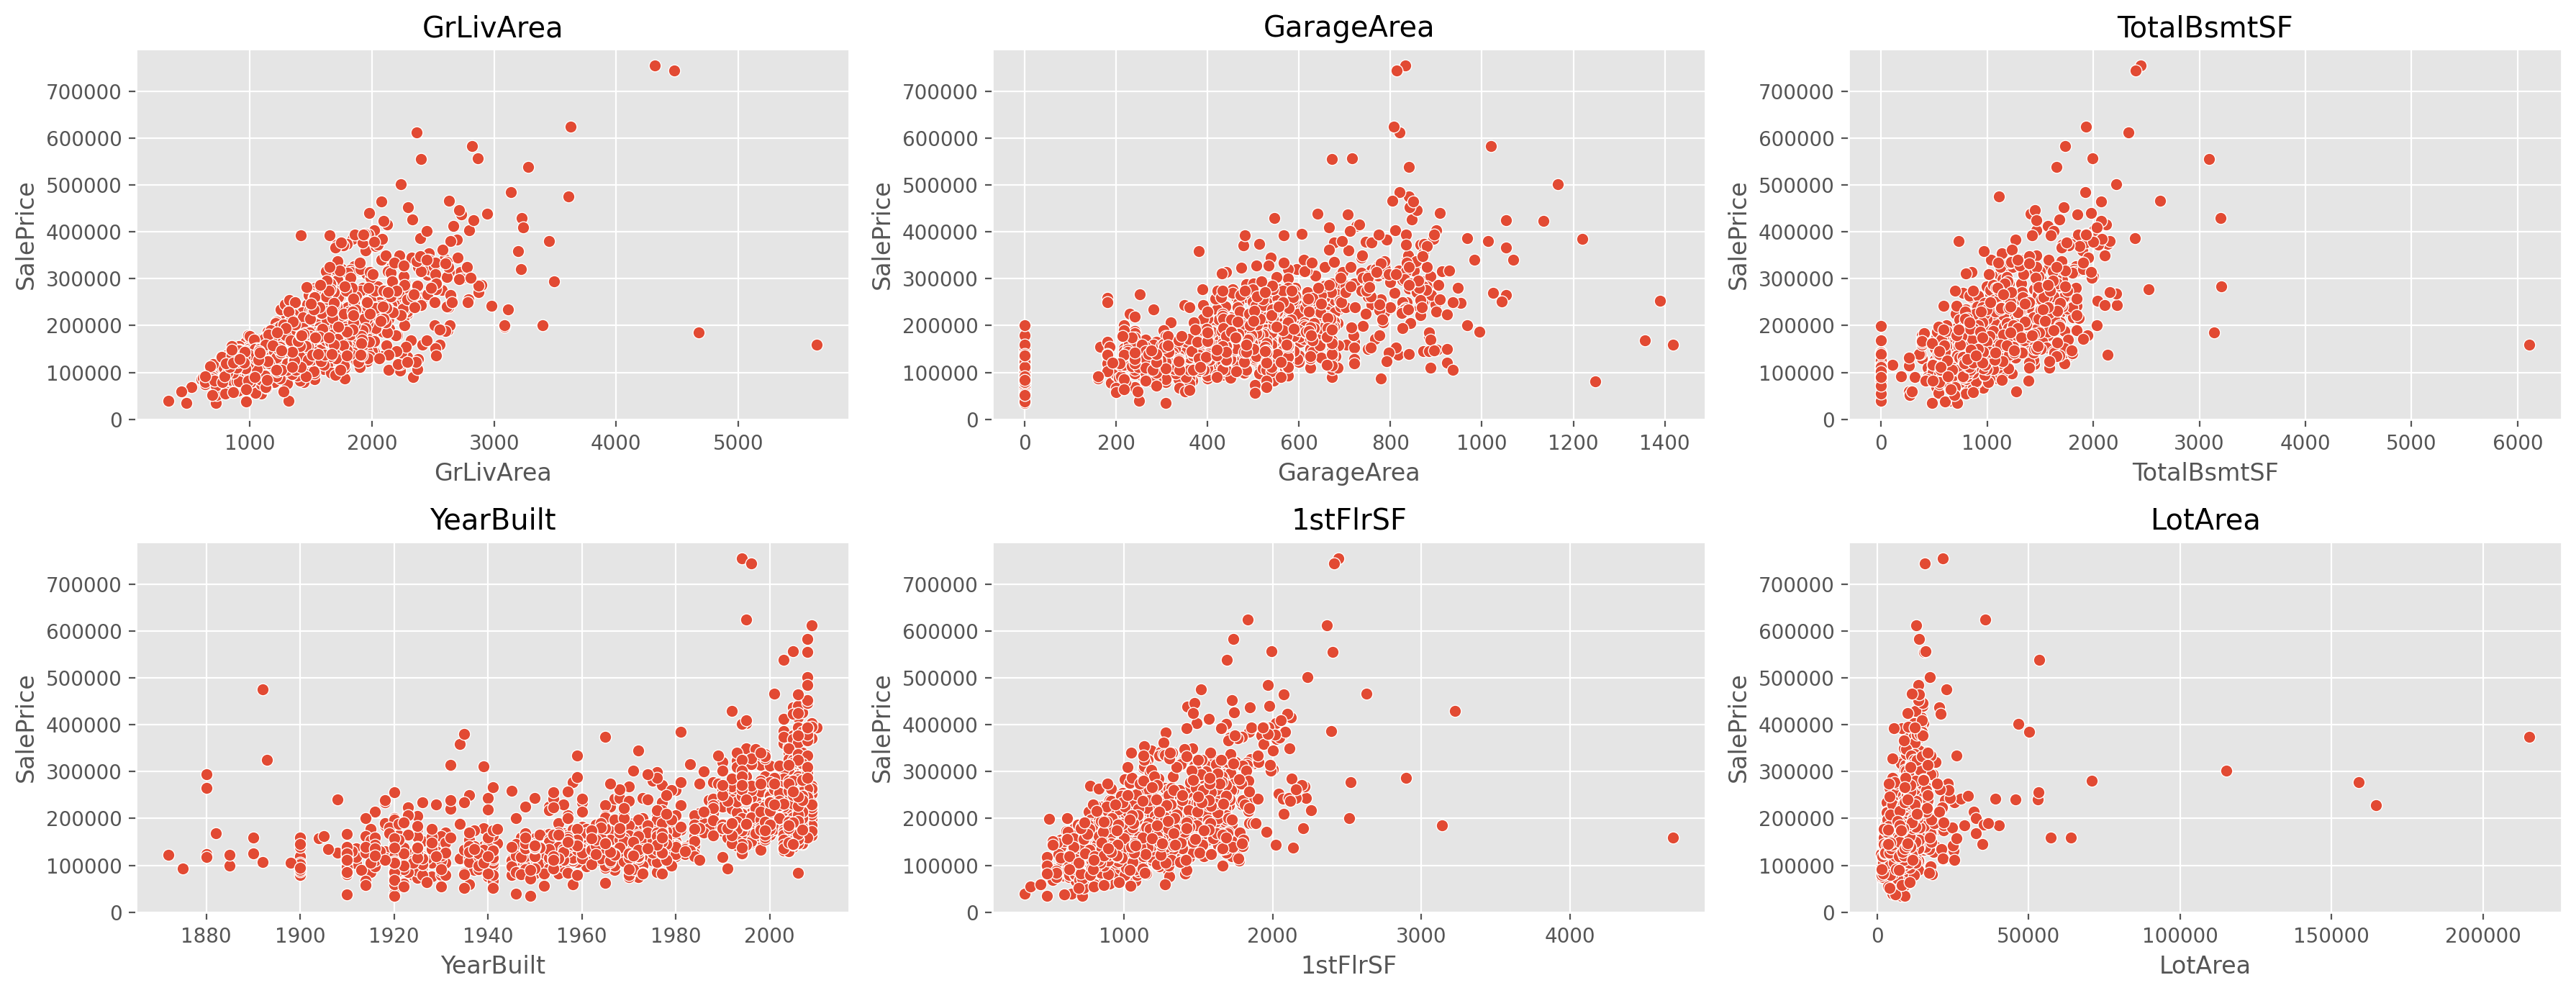

In [53]:
plt.figure(figsize=(18,7), dpi=200)

plt.subplot(2,3,1)
sns.scatterplot(x=data["GrLivArea"], y=data["SalePrice"])
plt.title("GrLivArea")

plt.subplot(2,3,2)
sns.scatterplot(x=data["GarageArea"], y=data["SalePrice"])
plt.title("GarageArea")

plt.subplot(2,3,3)
sns.scatterplot(x=data["TotalBsmtSF"], y=data["SalePrice"])
plt.title("TotalBsmtSF")

plt.subplot(2,3,4)
sns.scatterplot(x=data["YearBuilt"], y=data["SalePrice"])
plt.title("YearBuilt")

plt.subplot(2,3,5)
sns.scatterplot(x=data["1stFlrSF"], y=data["SalePrice"])
plt.title("1stFlrSF")

plt.subplot(2,3,6)
sns.scatterplot(x=data["LotArea"], y=data["SalePrice"])
plt.title("LotArea")

plt.tight_layout()
plt.show()

### Cheeching for outliers

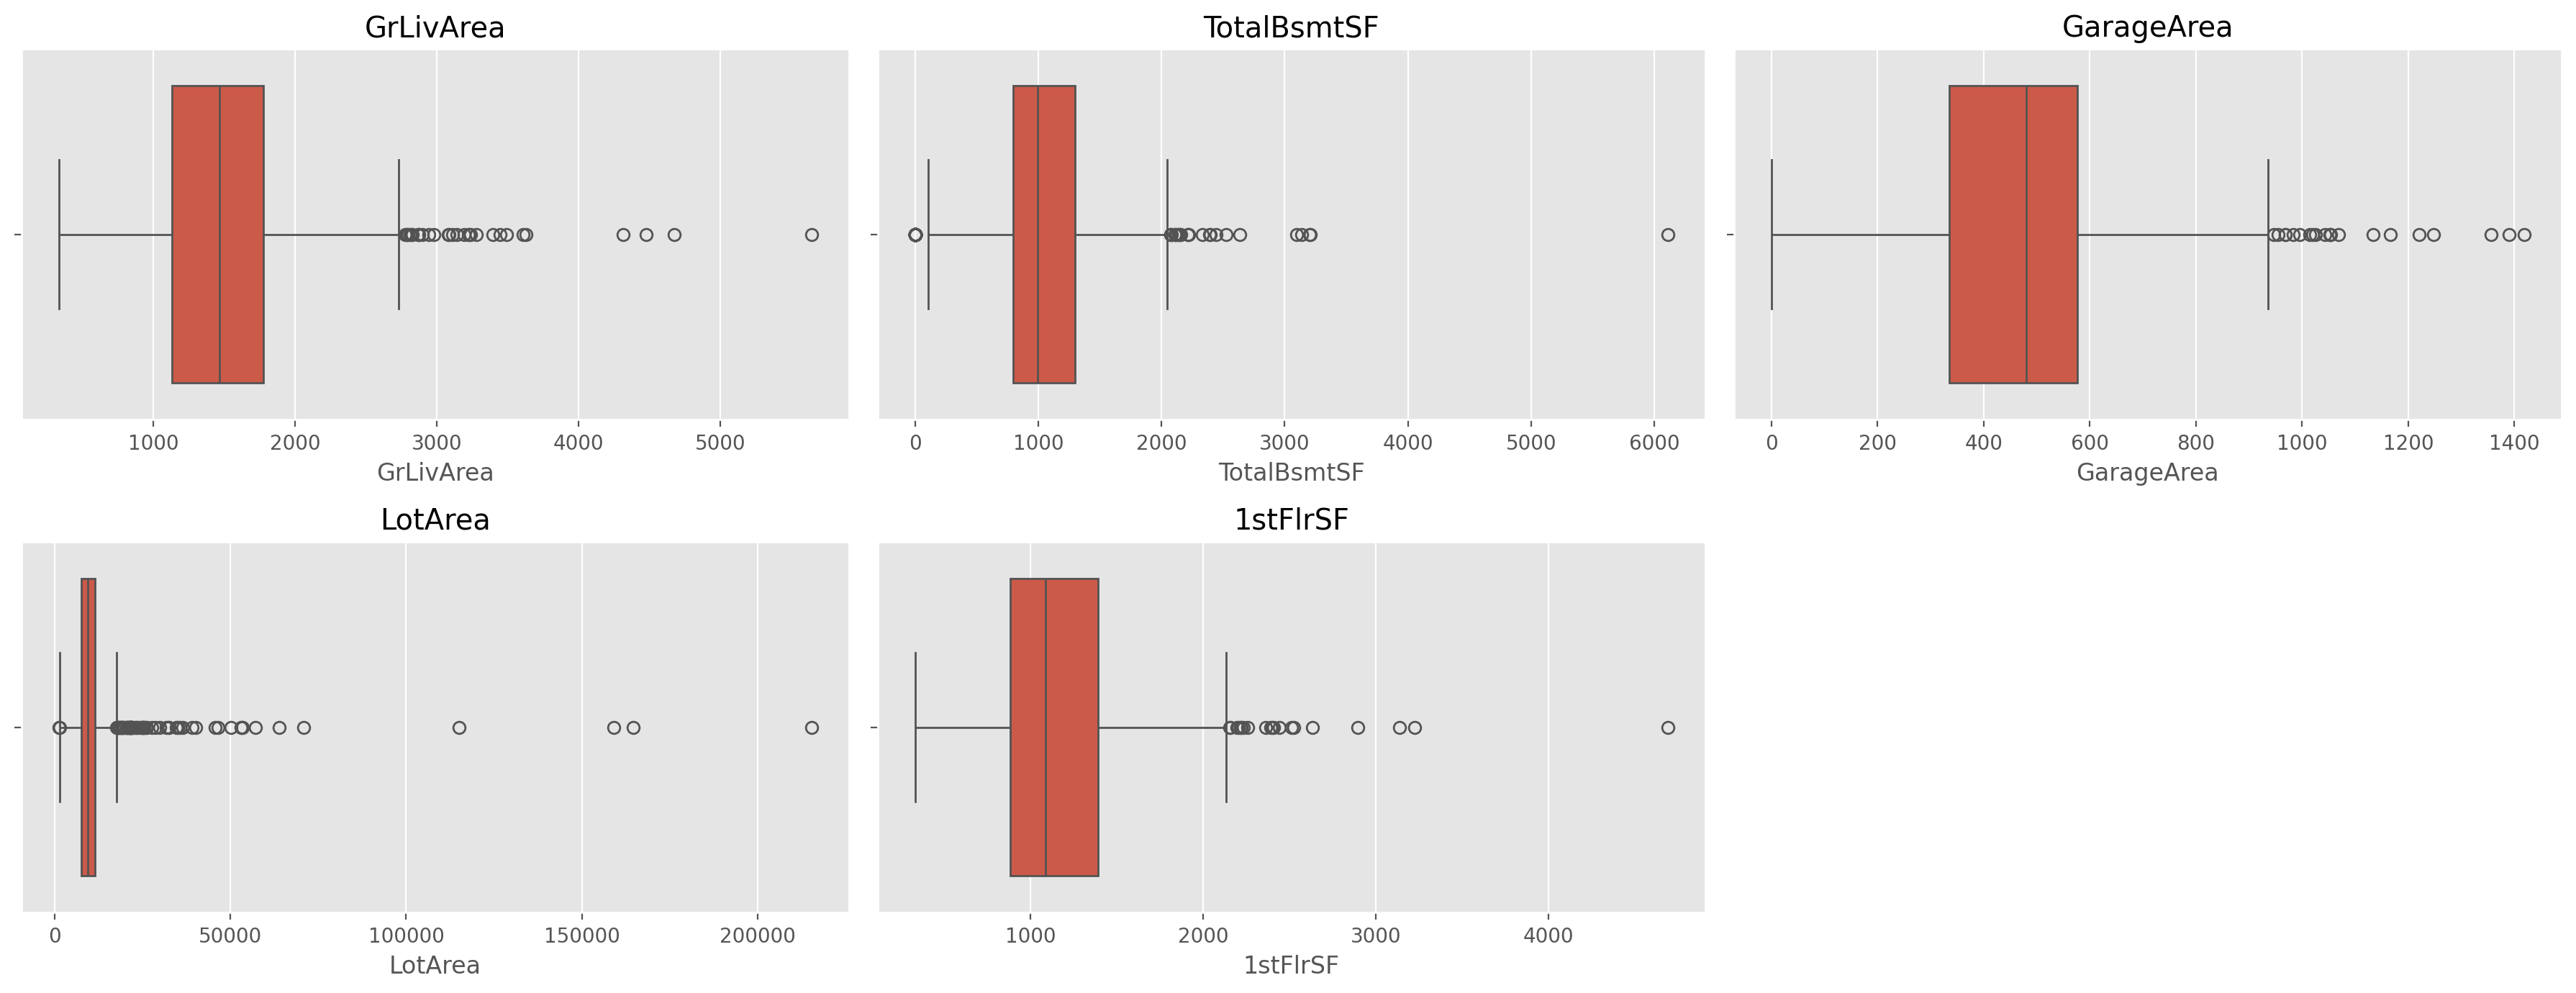

In [54]:
plt.figure(figsize=(18,7), dpi=200)

plt.subplot(2,3,1)
sns.boxplot(x=data["GrLivArea"])
plt.title("GrLivArea")

plt.subplot(2,3,2)
sns.boxplot(x=data["TotalBsmtSF"])
plt.title("TotalBsmtSF")

plt.subplot(2,3,3)
sns.boxplot(x=data["GarageArea"])
plt.title("GarageArea")

plt.subplot(2,3,4)
sns.boxplot(x=data["LotArea"])
plt.title("LotArea")

plt.subplot(2,3,5)
sns.boxplot(x=data["1stFlrSF"])
plt.title("1stFlrSF")

plt.tight_layout()
plt.show()

### 5. Remove outliers 

#### GrLivArea is considered to have outliers because some data points break the expected relationship between area and price (large area but low price)

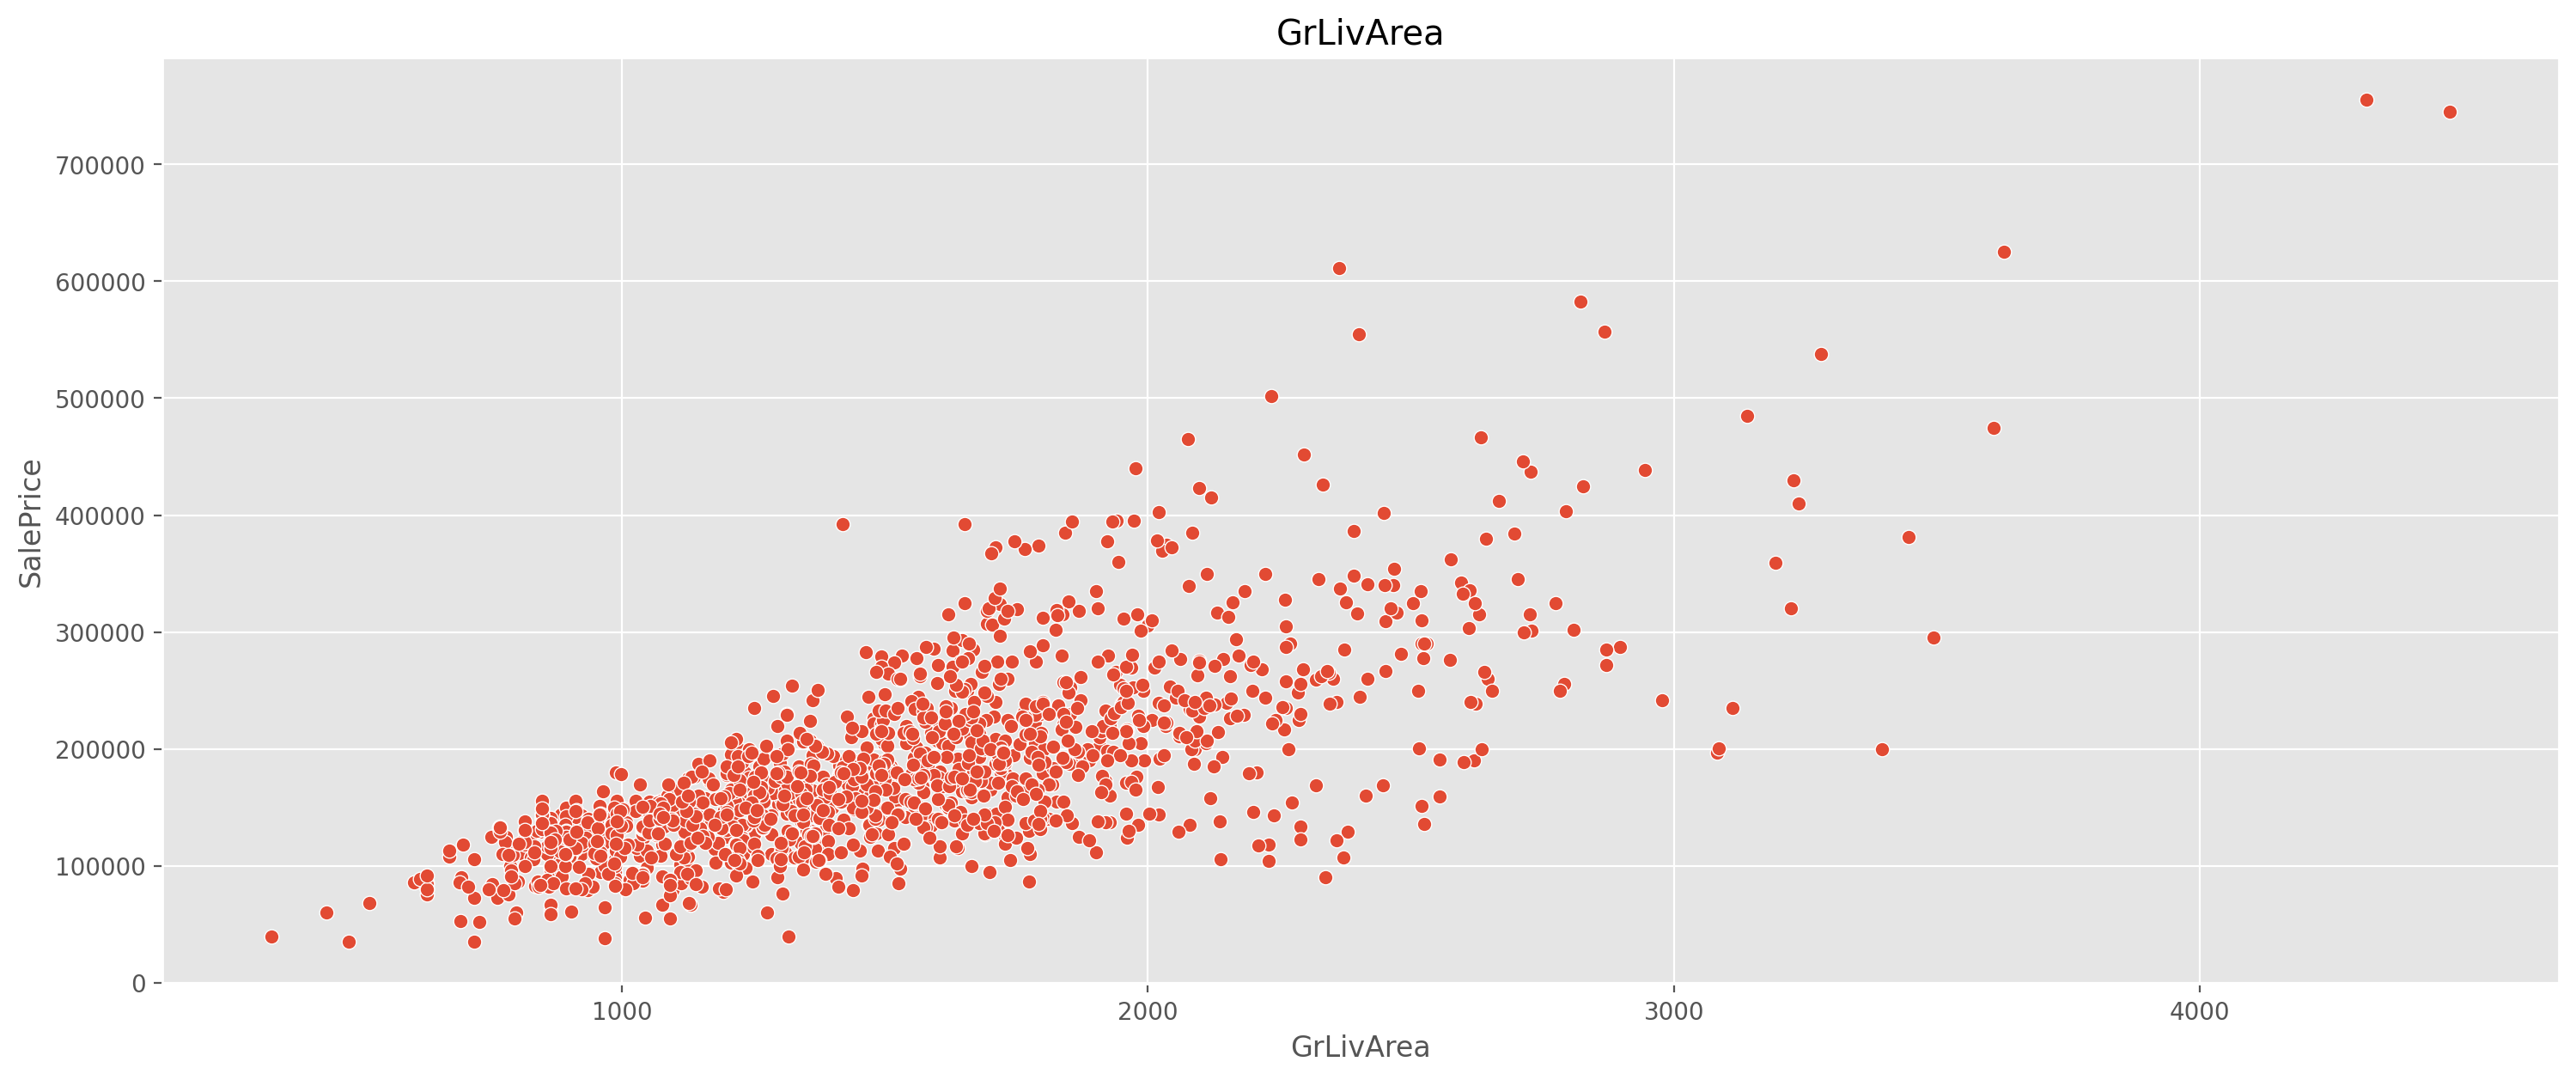

In [55]:
data = data[~((data["GrLivArea"] > 4000) & (data["SalePrice"] < 300000))]
plt.figure(figsize=(18,7), dpi=200)
sns.scatterplot(x=data["GrLivArea"], y=data["SalePrice"])
plt.title("GrLivArea")
plt.show()

### 5. Check the skewness of target

In [56]:
data["SalePrice"].skew() 

np.float64(1.8812964895244009)

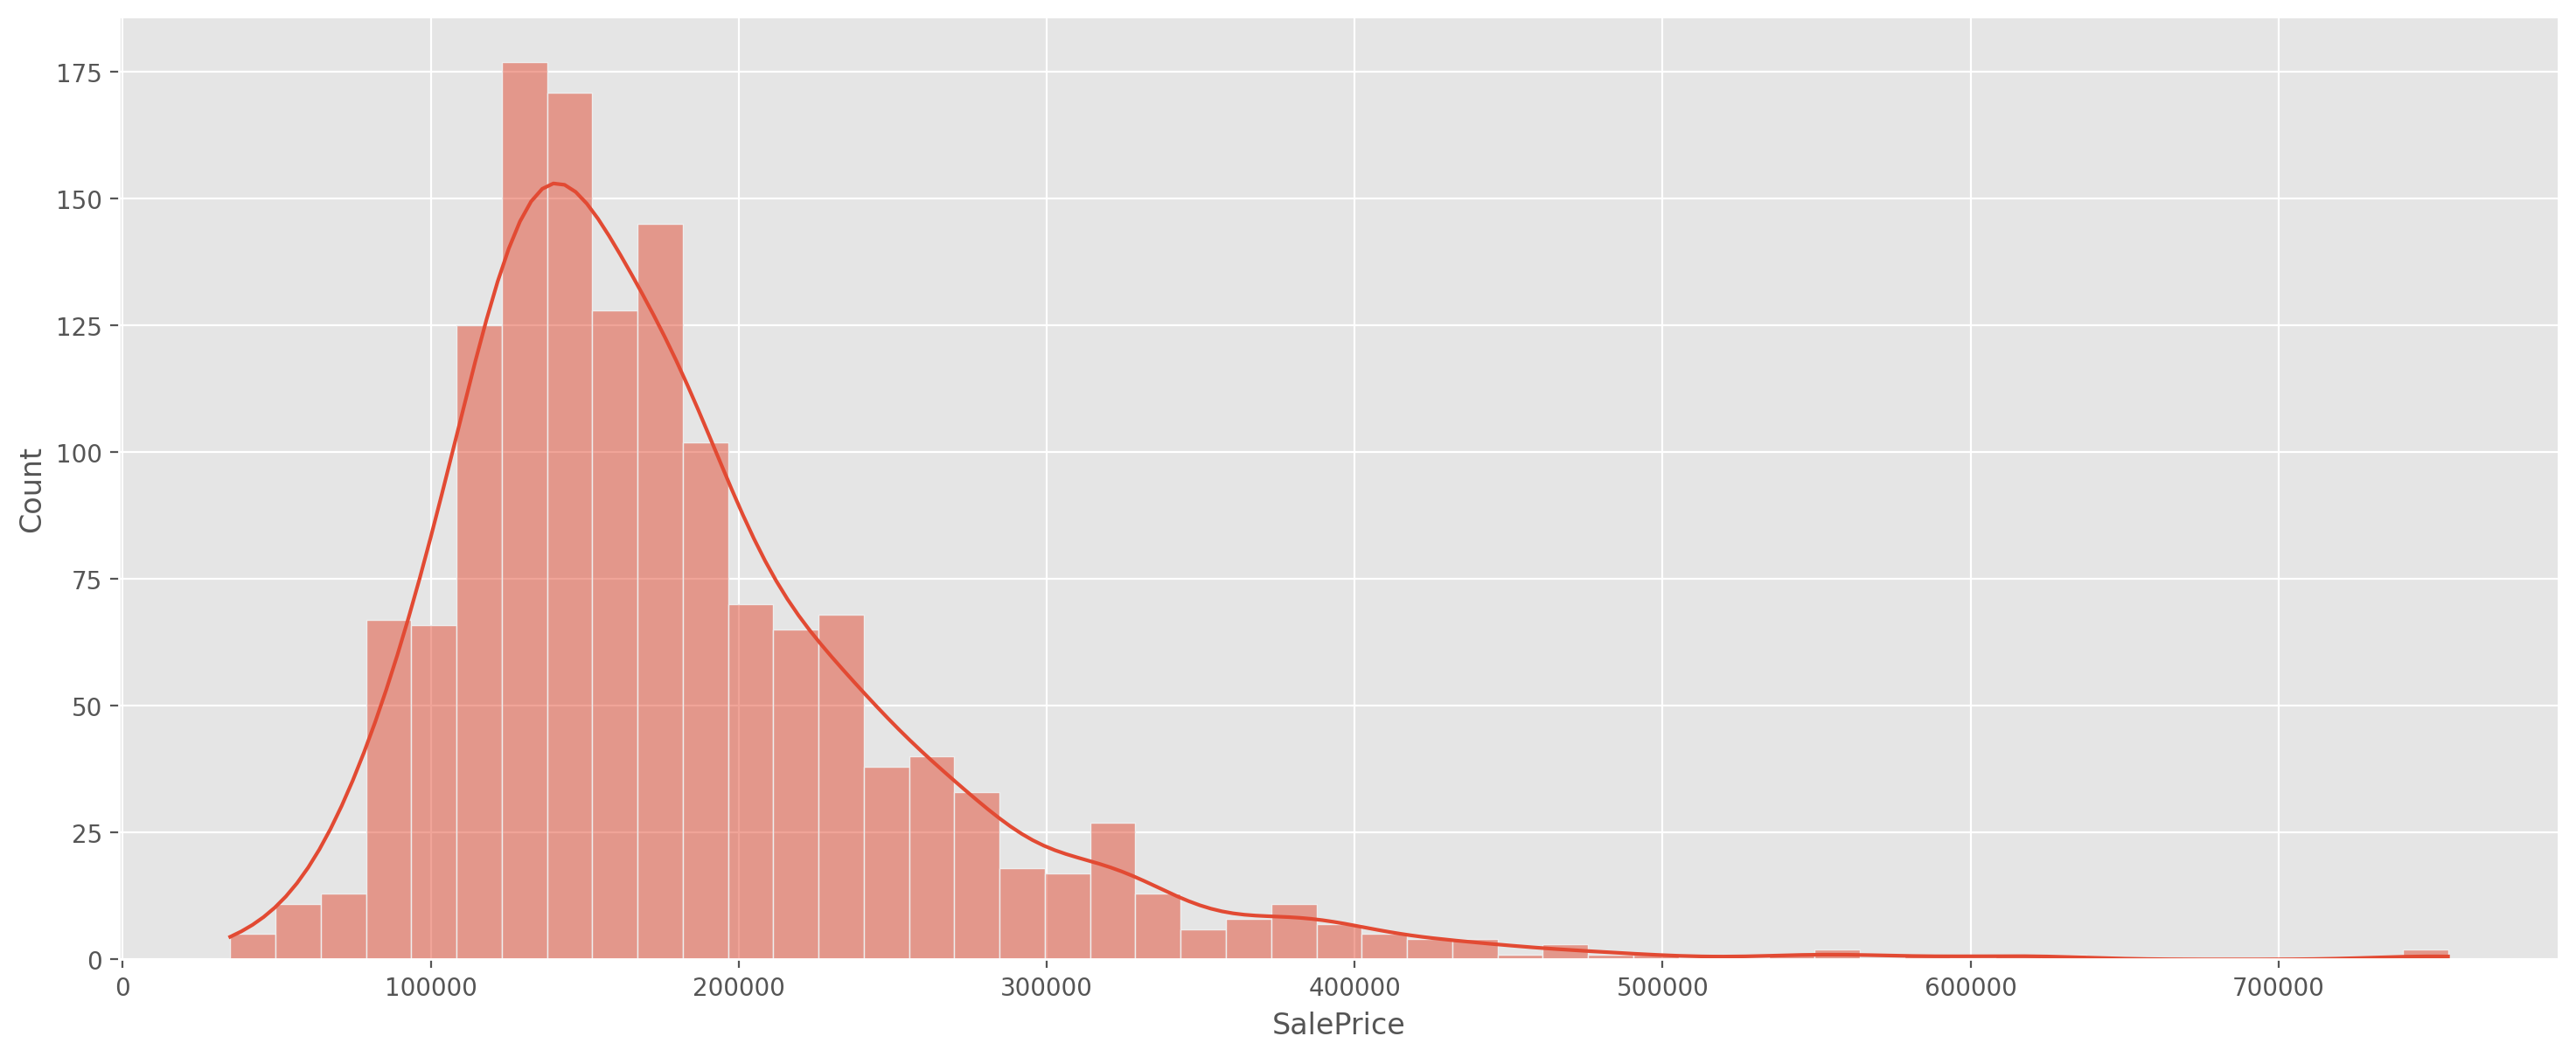

In [57]:
plt.figure(figsize = (18,7),dpi = 200)
sns.histplot(data["SalePrice"], kde=True)
plt.show() # its right skewed

### 6. Log tranform the target and replot it

#### The above plot show that the target is right skewed, models like linear regression we should tranform it using log due to sesitive nature of the model.

In [58]:
data["SalePrice"] = np.log1p(data["SalePrice"])

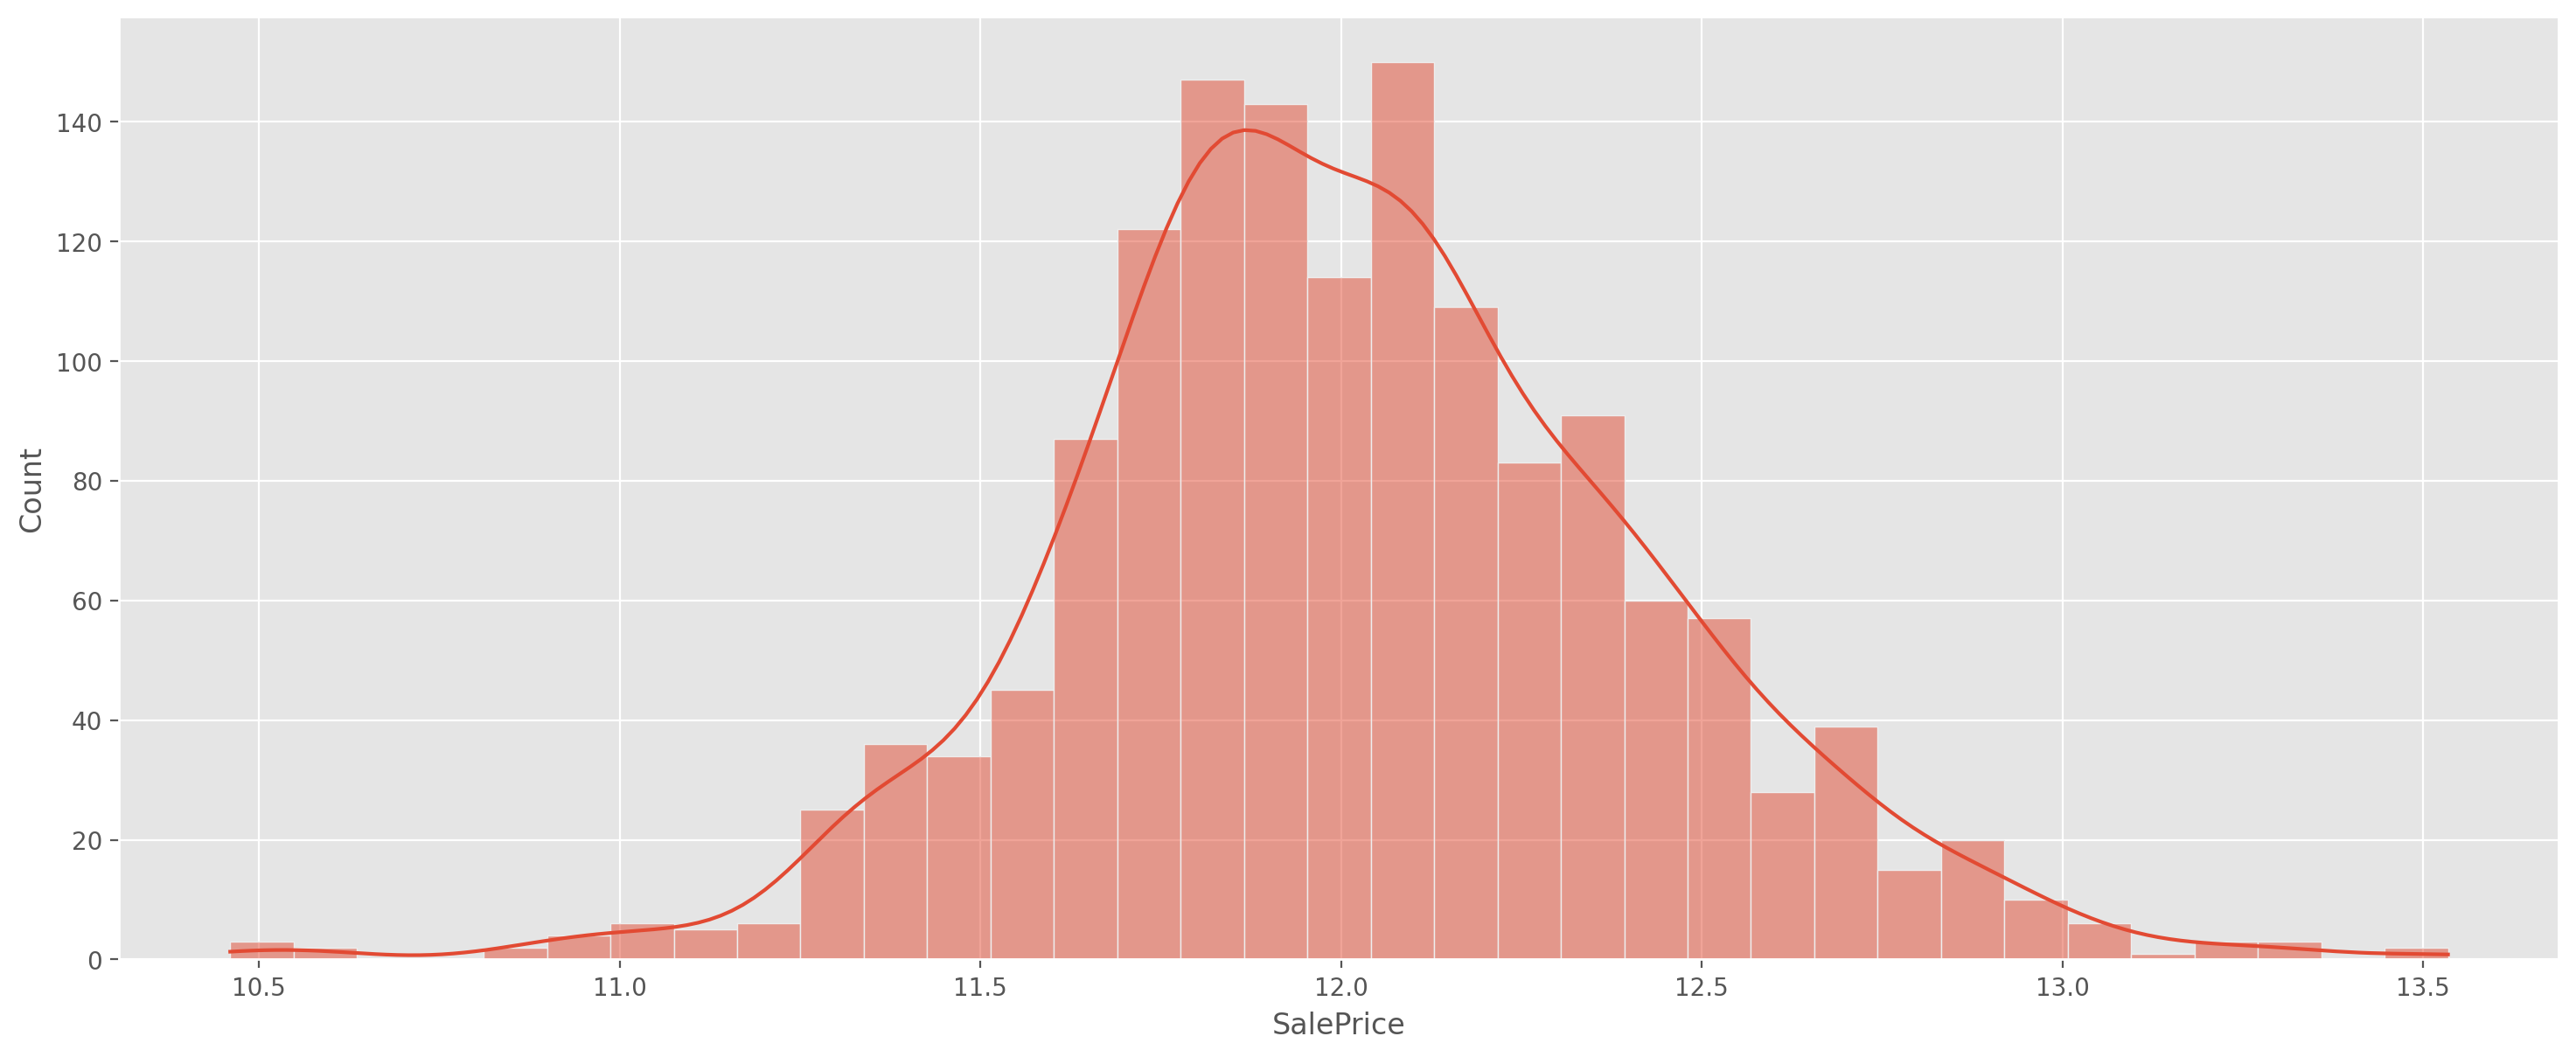

In [59]:
plt.figure(figsize = (18,7),dpi = 200)
sns.histplot(data["SalePrice"], kde=True)
plt.show() # The distrubution is much more normal when compared to teh original values of target

print("Shape of training dataset:", data.shape)
print("Shape of training dataset:", data.info())
print("Shape of training dataset:", data.dtypes)

---
---

## Feature Engineering

### 1. Check for missing values

In [61]:
missing_values = data.isnull().mean().sort_values(ascending=False)
print(missing_values.head(20))

PoolQC          0.995885
MiscFeature     0.962963
Alley           0.937586
Fence           0.807270
MasVnrType      0.598080
FireplaceQu     0.473251
LotFrontage     0.177641
GarageYrBlt     0.055556
GarageCond      0.055556
GarageType      0.055556
GarageFinish    0.055556
GarageQual      0.055556
BsmtExposure    0.026063
BsmtFinType2    0.026063
BsmtCond        0.025377
BsmtQual        0.025377
BsmtFinType1    0.025377
MasVnrArea      0.005487
Electrical      0.000686
MSSubClass      0.000000
dtype: float64


### 2. Train test split

In [62]:
x = data.drop("SalePrice", axis=1)
y = data["SalePrice"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=29)

In [63]:
categorical = x_train.select_dtypes(include=["object", "category"]).columns
categorical

Index(['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour',
       'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1',
       'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond',
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC',
       'Fence', 'MiscFeature', 'MoSold', 'YrSold', 'SaleType',
       'SaleCondition'],
      dtype='object')

In [64]:
numerical = x_train.select_dtypes(include=["int", "float"]).columns
numerical

Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal'],
      dtype='object')

### 3. Fill the missing values.
#### Few columns with None as missing value in these columns["PoolQC", "Alley", "Fence", "FireplaceQu"] means "not there"
1. Numerical with median
2. Categorical with mode.

In [65]:
cols = ["PoolQC", "Alley", "Fence", "FireplaceQu"]

for col in cols:
    x_train[col].fillna("None", inplace=True)
    x_test[col].fillna("None", inplace=True)

In [66]:
imputer = SimpleImputer(strategy="median")

x_train[numerical] = imputer.fit_transform(x_train[numerical])
x_test[numerical] = imputer.transform(x_test[numerical])

In [67]:
imputer_categorical = SimpleImputer(strategy="most_frequent")

x_train[categorical] = imputer_categorical.fit_transform(x_train[categorical])
x_test[categorical] = imputer_categorical.transform(x_test[categorical])

In [68]:
x_train.isnull().sum().sort_values(ascending=False).head(40)

MSSubClass       0
BedroomAbvGr     0
GarageType       0
FireplaceQu      0
Fireplaces       0
Functional       0
TotRmsAbvGrd     0
KitchenQual      0
KitchenAbvGr     0
HalfBath         0
GarageFinish     0
FullBath         0
BsmtHalfBath     0
BsmtFullBath     0
GrLivArea        0
LowQualFinSF     0
2ndFlrSF         0
1stFlrSF         0
GarageYrBlt      0
GarageCars       0
CentralAir       0
PoolArea         0
SaleType         0
YrSold           0
MoSold           0
MiscVal          0
MiscFeature      0
Fence            0
PoolQC           0
ScreenPorch      0
GarageArea       0
3SsnPorch        0
EnclosedPorch    0
OpenPorchSF      0
WoodDeckSF       0
PavedDrive       0
GarageCond       0
GarageQual       0
Electrical       0
HeatingQC        0
dtype: int64

### 3. Encoding only for categorical columns
1. Ordinal encoding where order metters like - "ExterQual", "KitchenQual", "BsmtQual"
2. Nominal encoding where order does not metter <br>
Separating the categorical columns in two parts

In [69]:
ordinal_columns = [
    "ExterQual", "KitchenQual", "BsmtQual",
    "GarageQual", "FireplaceQu", "HeatingQC",
    "BsmtCond", "GarageCond"
]

quality_order = ["None", "Po", "Fa", "TA", "Gd", "Ex"]
categories = [quality_order] * len(ordinal_columns)

encoding = OrdinalEncoder(categories=categories)

x_train[ordinal_columns] = encoding.fit_transform(x_train[ordinal_columns])
x_test[ordinal_columns] = encoding.transform(x_test[ordinal_columns])

In [70]:
nominal_columns = list(set(categorical) - set(ordinal_columns))

one_encoding = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

x_train_ohe = one_encoding.fit_transform(x_train[nominal_columns])
x_test_ohe = one_encoding.transform(x_test[nominal_columns])

In [71]:
ohe_cols = one_encoding.get_feature_names_out(nominal_columns)

x_train_ohe = pd.DataFrame(x_train_ohe, columns=ohe_cols, index=x_train.index)
x_test_ohe = pd.DataFrame(x_test_ohe, columns=ohe_cols, index=x_test.index)

In [72]:
x_train = x_train.drop(columns=nominal_columns)
x_test = x_test.drop(columns=nominal_columns)

x_train = pd.concat([x_train, x_train_ohe], axis=1)
x_test = pd.concat([x_test, x_test_ohe], axis=1)

In [73]:
x_train, x_test = x_train.align(x_test, join="left", axis=1, fill_value=0)

In [74]:
scale_cols = [
    "GrLivArea", "LotArea", "TotalBsmtSF",
    "1stFlrSF", "GarageArea"
]

scaler = StandardScaler()

x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

x_train_scaled[scale_cols] = scaler.fit_transform(x_train[scale_cols])
x_test_scaled[scale_cols] = scaler.transform(x_test[scale_cols])

---
---

## Model Training
1. Linear Regression
2. Random Forest
3. XGBoost

### 1. Linear Regression

In [75]:
regression = LinearRegression()
regression.fit(x_train_scaled, y_train)
y_pred_lr = regression.predict(x_test_scaled)

### 2. Random Forest

In [76]:
Forest = RandomForestRegressor(n_estimators=300, random_state=42)
Forest.fit(x_train, y_train)
y_pred_rf = Forest.predict(x_test)

### 3. XGBoost

In [77]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test) 

---
---

## Evaluation

In [78]:
y_test = np.expm1(y_test)
y_pred_lr= np.expm1(y_pred_lr)
y_pred_rf= np.expm1(y_pred_rf)
y_pred_xgb = np.expm1(y_pred_xgb)

In [79]:
print("Linear Regression RMSE:",r2_score(y_test, y_pred_lr),
      np.sqrt(mean_squared_error(y_test, y_pred_lr)))

print("Random Forest RMSE:",r2_score(y_test, y_pred_rf),
      np.sqrt(mean_squared_error(y_test, y_pred_rf)))

print("XGBoost RMSE:",r2_score(y_test, y_pred_xgb),
      np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

Linear Regression RMSE: 0.9249213575176876 18303.301555165162
Random Forest RMSE: 0.8819827320293296 22947.955954340236
XGBoost RMSE: 0.9043713333266133 20656.906299253034


---
---

## Conclustion:
1. Linear Regression performed best due to strong linear relationships in data.
2. Log tranformation was needed for target which helped the Linear regression model to learn the underlying patterns from data.

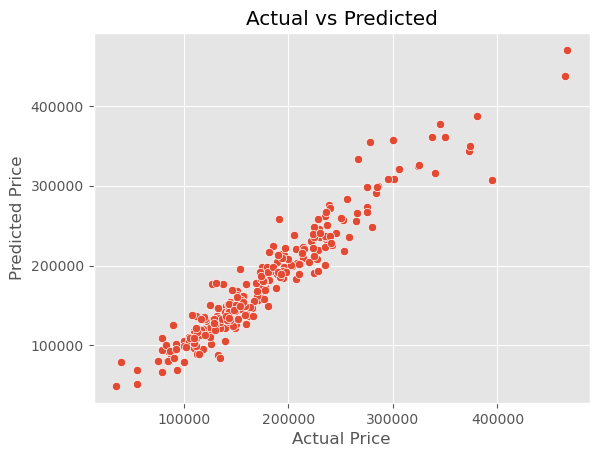

In [81]:
sns.scatterplot(x=y_test, y=y_pred_lr)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

---
---

## Lets check the feature importance for xbg and Random forest

In [89]:
# xgb
importance = pd.Series(xgb.feature_importances_, index=x_train.columns)
importance.sort_values(ascending=False).head(10)

OverallQual         0.245152
ExterQual           0.077617
GarageFinish_Unf    0.063793
GarageCars          0.062068
CentralAir_Y        0.058849
BsmtQual            0.042755
GrLivArea           0.037363
KitchenQual         0.036282
KitchenAbvGr        0.024571
FireplaceQu         0.020318
dtype: float32

In [90]:
# Random forest
importance_forest = pd.Series(Forest.feature_importances_, index=x_train.columns)
importance_forest.sort_values(ascending=False).head(10)

OverallQual    0.540535
GrLivArea      0.127944
TotalBsmtSF    0.048341
GarageArea     0.031393
GarageCars     0.023634
BsmtFinSF1     0.022310
YearBuilt      0.020561
1stFlrSF       0.016648
LotArea        0.013651
OverallCond    0.012659
dtype: float64

## Conclustion from the xgb and random forest:
1. From both models we see that the "OverallQual" is the most important feature for the model.
2. Linear Regression performed well because dataset is somewhat linear, XGBoost is more generalizable and scalable.


-----